In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
import sys
import pandas as pd
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("NLP tools successfully loaded!")



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Hermela\AppData\Roaming\nltk_data...


NLP tools successfully loaded!


In [13]:
sys.path.append(os.path.abspath("../"))
from src.eda_utilities import  load_data, assess_and_clean_missing_data, standardize_target_products,plot_categorical_distribution,plot_word_count_distribution,analyze_narrative_lengths
from src.text_normalization import execute_nlp_pipeline


root_folder = os.path.abspath("../")
input_path = os.path.join(root_folder, "data","raw","complaints.csv")
output_path = os.path.join(root_folder, "data","processed","complaintsCleaned.csv")




In [7]:
df_raw = load_data(input_path)

Loading data from: c:\Users\Hermela\Desktop\10academy\Week7\data\raw\complaints.csv


c:\Users\Hermela\Desktop\10academy\Week7\src\eda_utilities.py:17: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Shape  : 9,609,797 rows × 18 columns
Memory : 13284.4 MB


In [8]:
df_raw.dtypes

Date received                     str
Product                           str
Sub-product                       str
Issue                             str
Sub-issue                         str
Consumer complaint narrative      str
Company public response           str
Company                           str
State                             str
ZIP code                          str
Tags                              str
Consumer consent provided?        str
Submitted via                     str
Date sent to company              str
Company response to consumer      str
Timely response?                  str
Consumer disputed?                str
Complaint ID                    int64
dtype: object

In [10]:
print(df_raw['Product'].value_counts())

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

In [9]:
# Define the columns that CANNOT be blank
mandatory_columns = ['Product', 'Consumer complaint narrative']

# Run the function on your raw dataframe
df_cleaned = assess_and_clean_missing_data(df_raw, mandatory_columns)

--- Missing/Empty Critical Data Report ---
Product -> NaN count: 0 | Empty string count: 0
Consumer complaint narrative -> NaN count: 6,629,041 | Empty string count: 0
--------------------------------------------------
 Dropping rows with missing values in: ['Product', 'Consumer complaint narrative']

--- Cleaning Results ---
Rows before cleaning : 9,609,797
Rows after cleaning  : 2,980,756
Total rows dropped   : 6,629,041


In [13]:
standardize_target_products(df_cleaned,output_path)

distibution of products across the dataset
Product
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       26134
Name: count, dtype: int64

🎯 FINAL EDA: PIPELINE ASSESSMENT
Final Usable Dataset Size : 454,472 rows
Saved successfully!


In [14]:
df_final = load_data(output_path)
print(df_final['Product'].value_counts())


Loading data from: c:\Users\Hermela\Desktop\10academy\Week7\data\processed\complaintsCleaned.csv
Shape  : 454,472 rows × 18 columns
Memory : 983.8 MB
Product
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       26134
Name: count, dtype: int64


,Count,Percentage (%)
Product,,
Credit Card,189334,41.66
Savings Account,140319,30.88
Money Transfer,98685,21.71
Personal Loan,26134,5.75


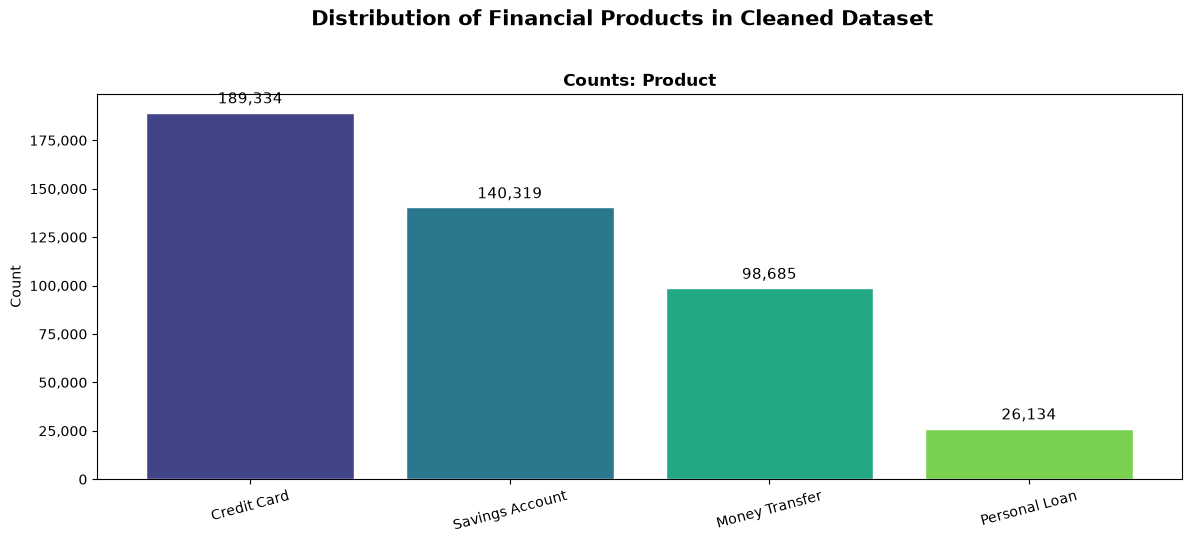

In [6]:
# Calling the general function with your specific CFPB data
plot_categorical_distribution(
    df=df_final, 
    categorical_col="Product", 
    title="Distribution of Financial Products in Cleaned Dataset"
)

In [7]:
# First, run the math and create the column
df_eda = analyze_narrative_lengths(df_final)


Analyzing narrative lengths for 'Consumer complaint narrative'...

 NARRATIVE LENGTH STATISTICAL SUMMARY
Total Records Analyzed : 454,472
Average Word Count     : 205.0 words
Median Word Count      : 136 words
Maximum Word Count     : 6,469 words


Generating distribution plot for 'word_count'...



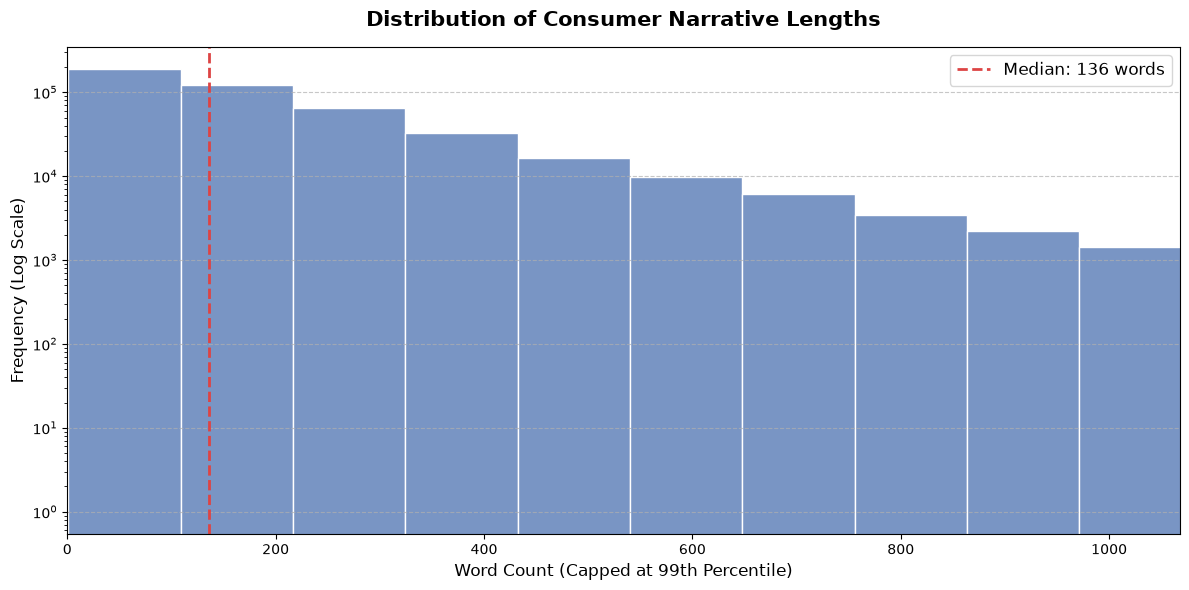

In [8]:
# Second, pass that updated dataframe to generate the graph
plot_word_count_distribution(df_eda)

In [16]:
print("Starting NLP text processing ")
# 1. Create a safe copy so we don't destroy our original loaded data
df_working = df_final.copy()
# 2. Apply the Master Pipeline to create the final processed column
df_working['Consumer complaint narrative'] = df_working['Consumer complaint narrative'].apply(execute_nlp_pipeline)

# 3. Drop any rows that became completely empty after we stripped the noise
df_normalized = df_working[df_working['Consumer complaint narrative'] != ""]

print("\nPipeline Complete! Here are the before-and-after results:\n")
print("="*80)
df_normalized.to_csv(output_path, index=False)
# Display a beautiful scrape of 3 random complaints to prove it worked
samples = df_normalized.sample(3, random_state=42)

for index, row in samples.iterrows():
    print(f"🔹 ORIGINAL TEXT:\n{row['Consumer complaint narrative'][:300]}...")
    print(f"🔸 PROCESSED TEXT:\n{row['Consumer complaint narrative'][:300]}...")
    print("-" * 80)

Starting NLP text processing 

Pipeline Complete! Here are the before-and-after results:

🔹 ORIGINAL TEXT:
receive text message think bank ask approve certain transaction georgia live california reply reply respond someone contact shortly individual contact include line improve customer service record line rather long phone call many pause seem know enough information question speak seem like typical cal...
🔸 PROCESSED TEXT:
receive text message think bank ask approve certain transaction georgia live california reply reply respond someone contact shortly individual contact include line improve customer service record line rather long phone call many pause seem know enough information question speak seem like typical cal...
--------------------------------------------------------------------------------
🔹 ORIGINAL TEXT:
file complaint cash app block inc due inadequate customer service unfair practice violate consumer financial protection act cfpa specifically cash app fail take timely e